### ADAML Quiz 5: Advanced Methods
Eetu Knutars, 17.10.2025

---

Setting up the environment

In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics.pairwise import rbf_kernel

np.random.seed(42)

Data loading, splitting to train and test sets with 75/25 split

In [28]:
df = pd.read_csv('Meter A', sep='\t', header=None)

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

X = df.iloc[:, :-1].values 
y = df.iloc[:, -1].values  

# Normalize X
X_true = X.copy()
X = (X - X.mean(axis=0)) / X.std(axis=0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

Seeing the relations with data features by plotting correlation matrix using the train set

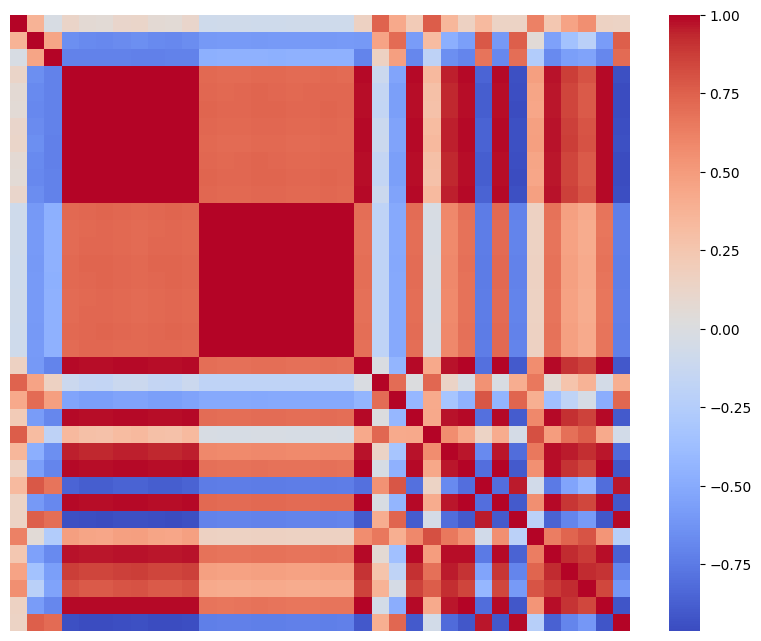

In [29]:
corr_matrix = np.corrcoef(X_train, rowvar=False)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', xticklabels=False, yticklabels=False)
plt.show()

From the correlation matrix we can see that there are strong correlations among some features (dark red and dark blue values). This indicates that PLS is more than required for this issue, since data is highly collinear. We will use kerne-PLS for the solutions, since the relation between features and the class is nonlinear (class is binary value, so we are doing logistic regression)

Use cross-validation for determining the number of components used for PLS

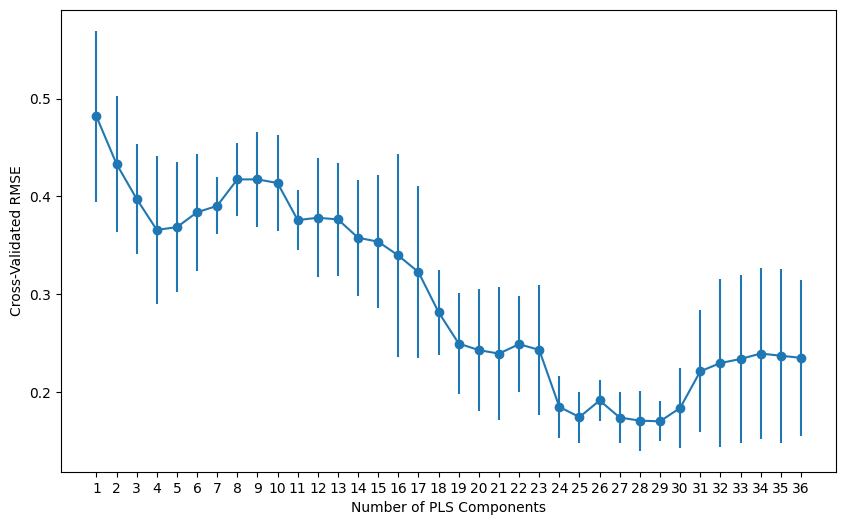

In [30]:
f = X_train.shape[1]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

components = list(range(1, f+1))
mean_rmse = []
std_rmse = []

for n_comp in components:
    pls = PLSRegression(n_components=n_comp)
    neg_mse_scores = cross_val_score(pls, X_train, y_train, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)
    rmse_scores = np.sqrt(-neg_mse_scores)
    mean_rmse.append(rmse_scores.mean())
    std_rmse.append(rmse_scores.std())

# Plot the RMSE values wrt. number of components
plt.figure(figsize=(10, 6))
plt.errorbar(components, mean_rmse, yerr=std_rmse, fmt='-o')
plt.xlabel('Number of PLS Components')
plt.ylabel('Cross-Validated RMSE')
plt.xticks(components)
plt.show()

In the RMSE plot we can see the first local minima when the number of components is 4. However after the first local minima, the RMSE value stedily drops all the way until 29 components, where the RMSE value is significantly smaller than at 4 so we should get the global minima value.

In [31]:
n_components = components[np.argmin(mean_rmse)]
print(f"Optimal number of components: {n_components}")

Optimal number of components: 29


Kernel matrices for train and test are centered based on the logic given in the task description, only translated to Python using numpy.

In [32]:
gamma = 0.1

# Train kernel
K_train = rbf_kernel(X_train, X_train, gamma=gamma)

n_train = K_train.shape[0]
oneN = np.ones((n_train, n_train)) / n_train
K_train_c = K_train - oneN @ K_train - K_train @ oneN + oneN @ K_train @ oneN

# Test kernel
K_test = rbf_kernel(X_test, X_train, gamma=gamma)

n_test = K_test.shape[0]
oneN_test = np.ones((n_test, n_train)) / n_train
K_test_c = K_test - oneN_test @ K_train - K_test @ oneN + oneN_test @ K_train @ oneN

Train accuracy: 1.00
Test accuracy: 0.86
Healthy class accuracy: 1.00
Faulty class accuracy: 0.83


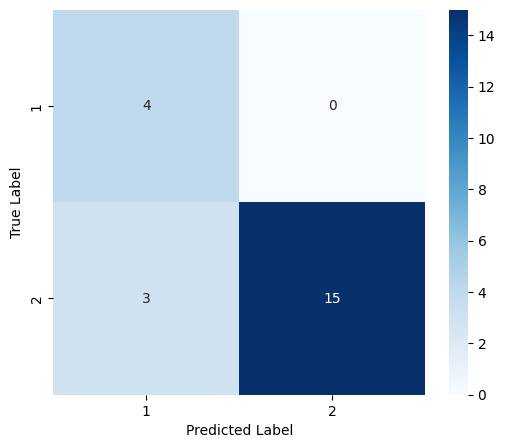

In [33]:
# Classifier function for returning the predicted classes
def predict(pls_model, K):
    y_pred_cont = pls_model.predict(K)
    y_pred_class = np.where(y_pred_cont.flatten() < 1.5, 1, 2)
    return y_pred_class

pls = PLSRegression(n_components=n_components)
T_train = pls.fit_transform(K_train_c, y_train)[0]
y_train_pred = predict(pls, K_train_c)
train_acc = (y_train_pred == y_train).mean()
print(f"Train accuracy: {train_acc:.2f}")

# Test the model
y_pred = predict(pls, K_test_c)

test_acc = (y_pred == y_test).mean()
print(f"Test accuracy: {test_acc:.2f}")

# Test class-wise accuracies
healthy_acc = (y_pred[y_test == 1] == 1).mean()
faulty_acc = (y_pred[y_test == 2] == 2).mean()

print(f"Healthy class accuracy: {healthy_acc:.2f}")
print(f"Faulty class accuracy: {faulty_acc:.2f}")

# Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[1, 2], yticklabels=[1, 2])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Test accuracy is 100%, and since test accuracy is below 90% there has likely been some overfitting in the model. 86% results is still decent for binary classifier.

Based on the class-wise accuracies, the model prefers classifying the data points as healthy. The accuracy for true healthy values is 100%, but with the true class being faulty (installation effects) the accuracy is 83%. Some of the data points with installation effects were classified as healthy by the model (false positives)